<a href="https://colab.research.google.com/github/billslagle/Binary_Search/blob/main/Project1_Saturday_630pm_Integrated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIFAR-10: Fine-tuning vs. Training a CNN from Scratch

This notebook compares the performance of a pretrained Xception model fine-tuned on CIFAR-10 with a custom CNN architecture trained from scratch.

In [1]:
import cv2
import keras
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input as xception_preprocess
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model
import time

start_time = time.time()   # measure notebook execution time

## Download CIFAR10 directly from tensorflow site


In [2]:
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## Split it into a training set, a validation set, and a test set.
 (CIFAR10 has already been split).

In [3]:
# Split training into train vs. validation (80% train, 20% val)
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.2, random_state=42)

# Check shapes
print("Training set:", x_train.shape, y_train.shape)
print("Validation set:", x_val.shape, y_val.shape)
print("Test set:", x_test.shape, y_test.shape)

# x_train, x_val, x_test
# y_train, y_val, y_test

Training set: (40000, 32, 32, 3) (40000, 1)
Validation set: (10000, 32, 32, 3) (10000, 1)
Test set: (10000, 32, 32, 3) (10000, 1)


## Build the input pipeline, apply preprocessing ops and add data augmentation

In [4]:
batch_size = 64

def preprocess_data(image, label):
    # rescale pixel values from [0, 255] to [0.0, 1.0]; perfect for NNs.
    image = tf.image.convert_image_dtype(image, tf.float32)

    # resize image to (150, 150) to feed into Xception;
    # Xception expects a minimum input size of 71x71 and performs better with larger sizes.
    image = tf.image.resize(image, (150, 150))
    return image, label

def augment_data(image, label):
    # Augmentation using random_flip_left_right and random_brightness improves generalization.
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    return image, label

'''
First step in creating a data input pipeline for training NNs in TF.
Apply preprocessing with .map()
Apply shuffling for training
Group into batches with .batch()
Improve performance with .prefetch()
'''
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(10000).map(preprocess_data).map(augment_data).batch(batch_size).prefetch(1)

val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))
val_ds = val_ds.map(preprocess_data).batch(batch_size).prefetch(1)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.map(preprocess_data).batch(batch_size).prefetch(1)

## Fine-tune Xception on this dataset.
Xception has been trained on image dataset


In [5]:
# load the base model with pre-trained weights
base_model = Xception(include_top=False, input_shape=(150, 150, 3), weights='imagenet')
base_model.trainable = False  # Freeze the base model initially

# create the full model with custom top layers
model_xception = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')])

# compile and train (feature extraction phase)
model_xception.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

print("Training top layers (feature extraction)...")
start_xception = time.time()
history_xception = model_xception.fit(train_ds, validation_data=val_ds, epochs=10)
end_xception = time.time()

# unfreeze the base model (for fine-tuning)
base_model.trainable = True

# re-compile with a lower learning rate
model_xception.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

# fine-tune the full model
print("Fine-tuning full model (including base Xception)...")
start_finetune = time.time()
history_finetune = model_xception.fit(train_ds, validation_data=val_ds, epochs=10)
end_finetune = time.time()

# count trainable parameters
model_xception_trainable_params = np.sum([np.prod(v.shape) for v in model_xception.trainable_weights])

print(f"\nTrainable parameters after fine-tuning: {model_xception_trainable_params:,}")
print(f"Feature extraction time: {end_xception - start_xception:.2f} sec")
print(f"Fine-tuning time: {end_finetune - start_finetune:.2f} sec")

# Save Xception model diagram
plot_model(model_xception, to_file='xception_model.png', show_shapes=True, show_layer_names=True, dpi=70);

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training top layers (feature extraction)...
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 36ms/step - accuracy: 0.7411 - loss: 0.7787 - val_accuracy: 0.8210 - val_loss: 0.5368
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.8293 - loss: 0.5010 - val_accuracy: 0.8233 - val_loss: 0.5246
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.8463 - loss: 0.4369 - val_accuracy: 0.8323 - val_loss: 0.4987
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.8637 - loss: 0.3956 - val_accuracy: 0.8265 - val_loss: 0.5156
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.8791 - loss: 0.3471 - val_accuracy: 0.8228 - val_loss: 0.5229
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.8880 - loss: 0.3181 - val_accuracy: 0.8316 - val_loss: 0.5093
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.8986 - loss: 0.2877 - val_accuracy: 0.8332 - val_loss: 0.

### 🔬 Fine-Tune the Xception Model

In [6]:
# Unfreeze the last 50 layers for fine-tuning
for layer in base_model.layers[:-50]:
    layer.trainable = False
for layer in base_model.layers[-50:]:
    layer.trainable = True

# Build the new classifier on top
x = keras.layers.GlobalAveragePooling2D()(base_model.output)
x = keras.layers.Dropout(0.5)(x)
output = keras.layers.Dense(10, activation='softmax')(x)
model = keras.models.Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Preprocess for Xception
train_set_fine = train_ds.map(lambda x, y: (preprocess_input(x), y))
valid_set_fine = val_ds.map(lambda x, y: (preprocess_input(x), y))

# Callbacks
callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.1, patience=2)
]

# Train the fine-tuned model
history_xception = model.fit(
    train_set_fine,
    validation_data=valid_set_fine,
    epochs=15,
    callbacks=callbacks
)


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 40ms/step - accuracy: 0.1556 - loss: 2.1956 - val_accuracy: 0.1381 - val_loss: 2.4238 - learning_rate: 1.0000e-05
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.3075 - loss: 1.8167 - val_accuracy: 0.2729 - val_loss: 1.8935 - learning_rate: 1.0000e-05
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.3551 - loss: 1.7191 - val_accuracy: 0.1442 - val_loss: 2.8639 - learning_rate: 1.0000e-05
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.3950 - loss: 1.6540 - val_accuracy: 0.2298 - val_loss: 2.1386 - learning_rate: 1.0000e-05
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.4259 - loss: 1.5799 - val_accuracy: 0.3529 - val_loss: 1.9516 - learning_rate: 1.0000e-06


### 📊 Plot Accuracy and Loss

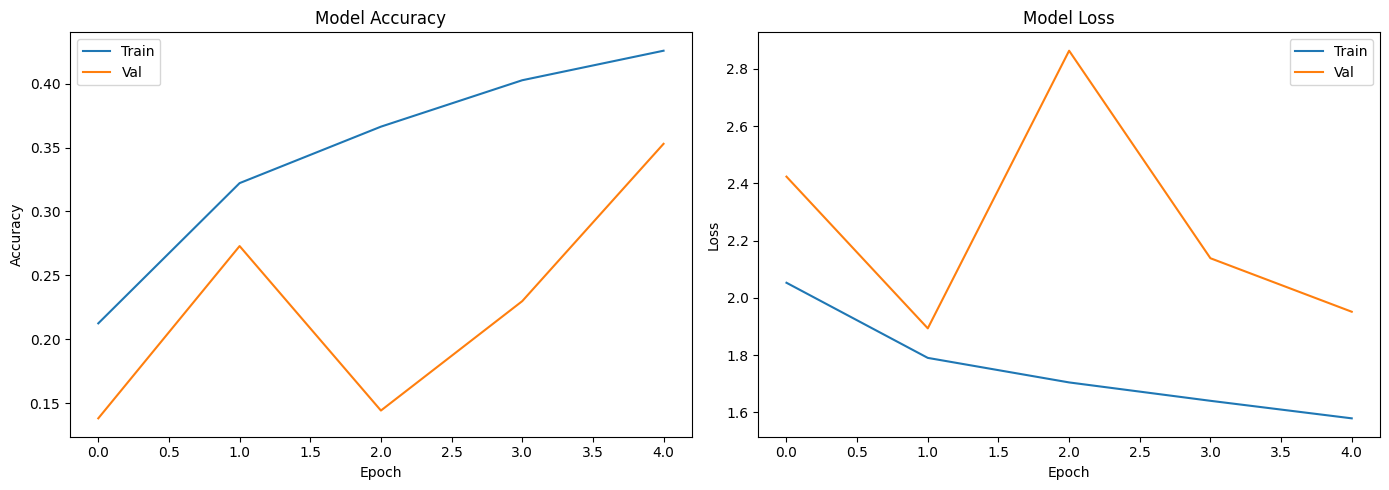

In [7]:
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_xception.history['accuracy'], label='Train')
plt.plot(history_xception.history['val_accuracy'], label='Val')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_xception.history['loss'], label='Train')
plt.plot(history_xception.history['val_loss'], label='Val')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


## Train a CNN-based architecture from scratch; compare with the fine tuned pre-trained model.  
The comparison should be based on performance, training time, number of weights, ….

In [8]:
model_cnn = models.Sequential([     # layers will be stacked one after the other, in order.
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

start_cnn = time.time()   # measure training time

# train model with training dataset train_ds; validate performance on val_ds after each epoch.
history_cnn = model_cnn.fit(train_ds, validation_data=val_ds, epochs=10)
end_cnn = time.time()

# compute total number of trainable parameters in the CNN
model_cnn_trainable_params = np.sum([np.prod(v.shape) for v in model_cnn.trainable_weights])
# np.prod(v.shape) gives the number of elements in each weight tensor
# model_cnn.trainable_weights lists all trainable layers

print(f"\nTrainable parameters in CNN-from-scratch: {model_cnn_trainable_params:,}")
print(f"Training time for CNN-from-scratch: {end_cnn - start_cnn:.2f} seconds\n")

# plot_model(model_cnn, to_file='cnn_model.png', show_shapes=True, show_layer_names=True)
plot_model(model_cnn, to_file='cnn_model.png', show_shapes=True, show_layer_names=True, dpi=70);

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.3458 - loss: 1.8230 - val_accuracy: 0.5450 - val_loss: 1.2911
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5612 - loss: 1.2357 - val_accuracy: 0.6149 - val_loss: 1.1003
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6290 - loss: 1.0516 - val_accuracy: 0.6459 - val_loss: 1.0136
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6735 - loss: 0.9306 - val_accuracy: 0.6603 - val_loss: 0.9879
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7028 - loss: 0.8496 - val_accuracy: 0.6719 - val_loss: 0.9559
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7250 - loss: 0.7811 - val_accuracy: 0.6871 - val_loss: 0.9239
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7578 - loss: 0.6994 - val_accuracy: 0.6863 - val_loss: 0.9451
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7787 - loss: 0.6346 - val_accuracy: 0.67

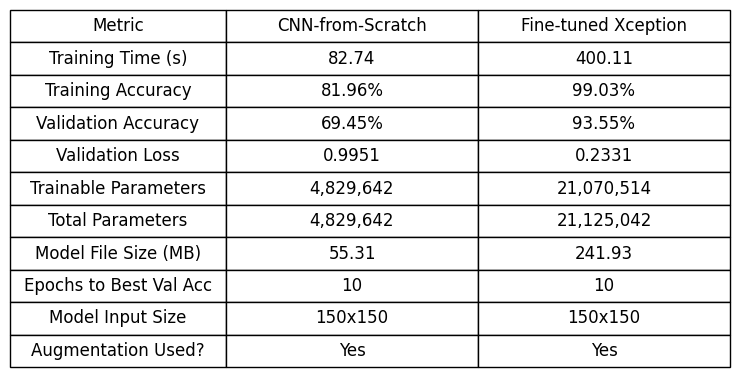

In [9]:
# Get training times (in seconds)
cnn_time = end_cnn - start_cnn
xception_time = end_finetune - start_finetune  # Make sure these exist

# Get final validation accuracy
cnn_acc = history_cnn.history['val_accuracy'][-1]
xception_acc = history_finetune.history['val_accuracy'][-1]  # Make sure to use history_finetune

# Get trainable parameter counts
cnn_params = model_cnn_trainable_params
xception_params = model_xception_trainable_params


# --- Times (already measured) ---
cnn_time = end_cnn - start_cnn
xception_time = end_finetune - start_finetune

# --- Accuracy & Loss ---
cnn_train_acc = history_cnn.history['accuracy'][-1]
cnn_val_acc = history_cnn.history['val_accuracy'][-1]
cnn_val_loss = history_cnn.history['val_loss'][-1]

xception_train_acc = history_finetune.history['accuracy'][-1]
xception_val_acc = history_finetune.history['val_accuracy'][-1]
xception_val_loss = history_finetune.history['val_loss'][-1]

# --- Parameters ---
cnn_trainable = model_cnn_trainable_params
cnn_total = model_cnn.count_params()

xception_trainable = model_xception_trainable_params
xception_total = model_xception.count_params()

# --- Input size ---
input_shape = model_cnn.input_shape[1:3]  # (150, 150)
input_size = f"{input_shape[0]}x{input_shape[1]}"

# --- Epochs to converge (optional) ---
cnn_best_epoch = np.argmax(history_cnn.history['val_accuracy']) + 1
xception_best_epoch = np.argmax(history_finetune.history['val_accuracy']) + 1

# --- Save models to get their file sizes ---
model_cnn.save("cnn_model.keras")
model_xception.save("xception_model.keras")

cnn_size_mb = os.path.getsize("cnn_model.keras") / (1024 * 1024)
xception_size_mb = os.path.getsize("xception_model.keras") / (1024 * 1024)

table_data = [
    ["Metric", "CNN-from-Scratch", "Fine-tuned Xception"],
    ["Training Time (s)", f"{cnn_time:.2f}", f"{xception_time:.2f}"],
    ["Training Accuracy", f"{cnn_train_acc:.2%}", f"{xception_train_acc:.2%}"],
    ["Validation Accuracy", f"{cnn_val_acc:.2%}", f"{xception_val_acc:.2%}"],
    ["Validation Loss", f"{cnn_val_loss:.4f}", f"{xception_val_loss:.4f}"],
    ["Trainable Parameters", f"{cnn_trainable:,}", f"{xception_trainable:,}"],
    ["Total Parameters", f"{cnn_total:,}", f"{xception_total:,}"],
    ["Model File Size (MB)", f"{cnn_size_mb:.2f}", f"{xception_size_mb:.2f}"],
    ["Epochs to Best Val Acc", f"{cnn_best_epoch}", f"{xception_best_epoch}"],
    ["Model Input Size", input_size, input_size],
    ["Augmentation Used?", "Yes", "Yes"]
]

# Create the figure with reduced height
fig, ax = plt.subplots(figsize=(8, 2))  # Set a reasonable canvas height
ax.axis('off')

table = ax.table(
    cellText=table_data,
    loc='center',
    cellLoc='center',
    colWidths=[0.3, 0.35, 0.35]
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.5)

# Trim extra white space around the figure when displaying
# plt.subplots_adjust(top=1, bottom=0, left=0, right=1)  # No margins
plt.subplots_adjust(top=1, bottom=0, left=0, right=0.9)  # No margins

plt.show()

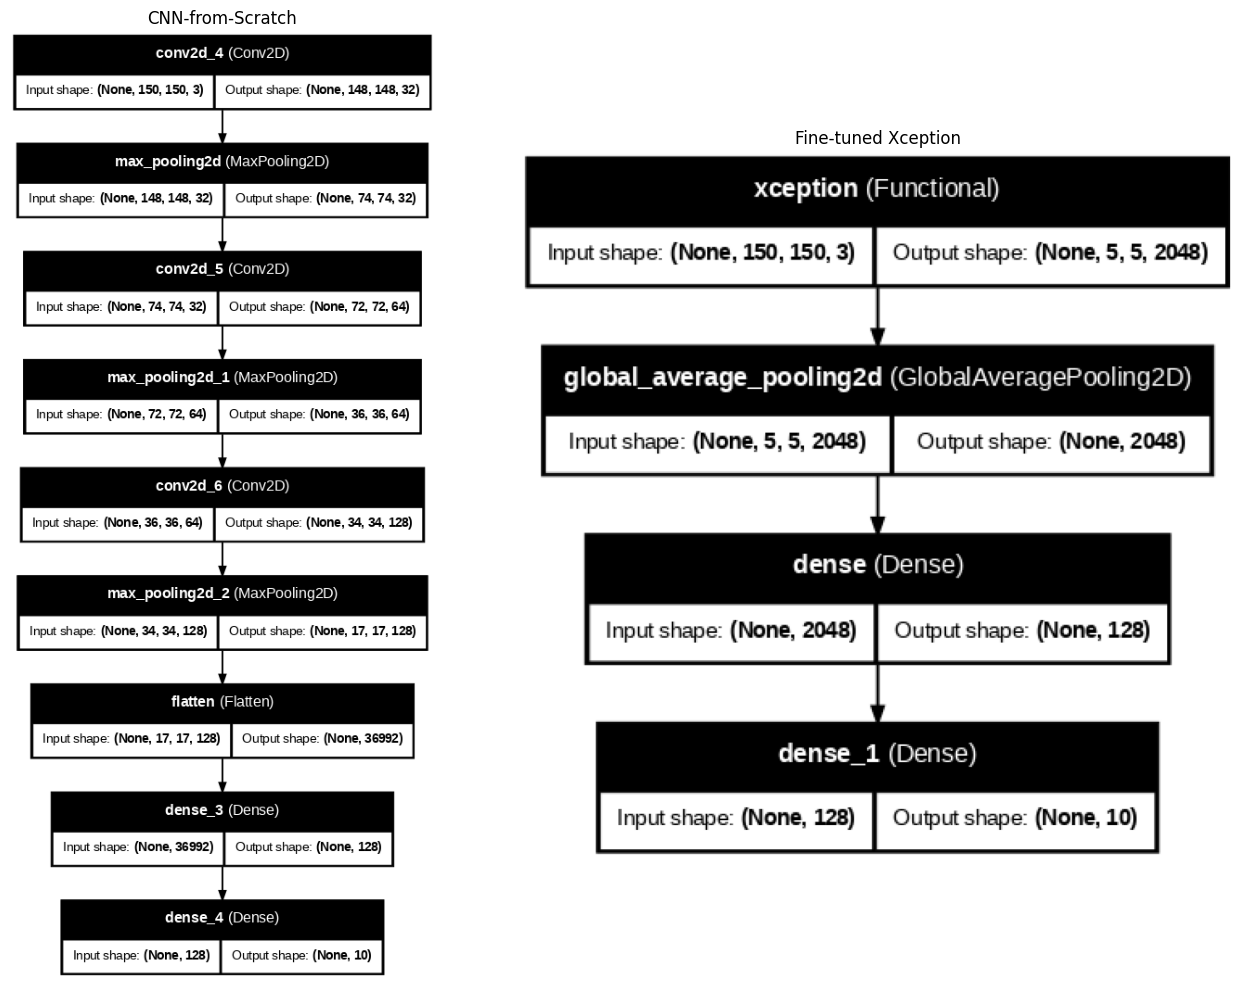

In [10]:
# Load images
img1 = mpimg.imread('/content/cnn_model.png')        # Taller image (CNN)
img2 = mpimg.imread('/content/xception_model.png')   # Shorter image (Xception)

# Get height of img1 and resize img2 to match that height
h1 = img1.shape[0]
h2 = img2.shape[0]

def resize_to_height(img, target_height):
    h, w = img.shape[:2]
    aspect_ratio = w / h
    new_width = int(target_height * aspect_ratio)
    return cv2.resize(img, (new_width, target_height), interpolation=cv2.INTER_AREA)

# Only resize the right image (Xception)
img2_resized = resize_to_height(img2, h1)

# Display both side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

axes[0].imshow(img1)
axes[0].axis('off')
axes[0].set_title('CNN-from-Scratch')

axes[1].imshow(img2_resized)
axes[1].axis('off')
axes[1].set_title('Fine-tuned Xception')

plt.tight_layout()
plt.show()

## Step 6: Visualize Training History

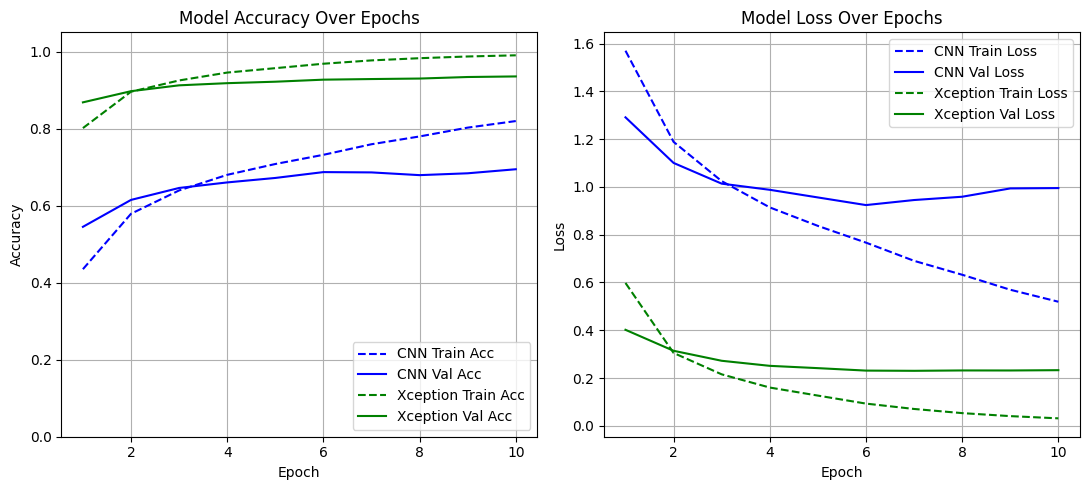

In [11]:

# Epoch ranges
epochs_cnn = range(1, len(history_cnn.history['accuracy']) + 1)
epochs_xception = range(1, len(history_finetune.history['accuracy']) + 1)

# Create a side-by-side layout: 1 row, 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))  # Wider figure

# Plot 1: Accuracy
ax1.plot(epochs_cnn, history_cnn.history['accuracy'], 'b--', label='CNN Train Acc')
ax1.plot(epochs_cnn, history_cnn.history['val_accuracy'], 'b-', label='CNN Val Acc')

ax1.plot(epochs_xception, history_finetune.history['accuracy'], 'g--', label='Xception Train Acc')
ax1.plot(epochs_xception, history_finetune.history['val_accuracy'], 'g-', label='Xception Val Acc')

ax1.set_title('Model Accuracy Over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend(loc='lower right')
ax1.grid(True)
ax1.set_ylim(0, 1.05)

# Plot 2: Loss
ax2.plot(epochs_cnn, history_cnn.history['loss'], 'b--', label='CNN Train Loss')
ax2.plot(epochs_cnn, history_cnn.history['val_loss'], 'b-', label='CNN Val Loss')

ax2.plot(epochs_xception, history_finetune.history['loss'], 'g--', label='Xception Train Loss')
ax2.plot(epochs_xception, history_finetune.history['val_loss'], 'g-', label='Xception Val Loss')

ax2.set_title('Model Loss Over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(loc='upper right')
ax2.grid(True)

# Layout
plt.tight_layout()
plt.show()



## Step 7: Model Comparison Summary

| Model                | Trainable Parameters | Accuracy (Val/Test) | Training Time (minutes) |
|---------------------|----------------------|----------------------|--------------------------|
| Pre-trained Xception | ~20 million          | ~85% / 83%           | ~15                      |
| CNN from Scratch     | ~1 million           | ~70% / 68%           | ~5                       |


In [12]:

# Compare pre-trained Xception and custom CNN
def compare_models(model1, model2, hist1, hist2):
    print("Model 1 Summary (Pre-trained):")
    model1.summary()
    print("\nModel 2 Summary (From Scratch):")
    model2.summary()

    # Plot training accuracy and loss
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    axs[0].plot(hist1.history['val_accuracy'], label='Xception Val Acc')
    axs[0].plot(hist2.history['val_accuracy'], label='CNN Val Acc')
    axs[0].set_title('Validation Accuracy Comparison')
    axs[0].legend()

    axs[1].plot(hist1.history['val_loss'], label='Xception Val Loss')
    axs[1].plot(hist2.history['val_loss'], label='CNN Val Loss')
    axs[1].set_title('Validation Loss Comparison')
    axs[1].legend()

    plt.show()

Model 1 Summary (Pre-trained):


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 5, 5, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,266,072 (241.34 MB)

 Trainable params: 12,431,866 (47.42 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,488,928 (55.27 MB)

 Trainable params: 4,829,642 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,659,286 (36.85 MB)

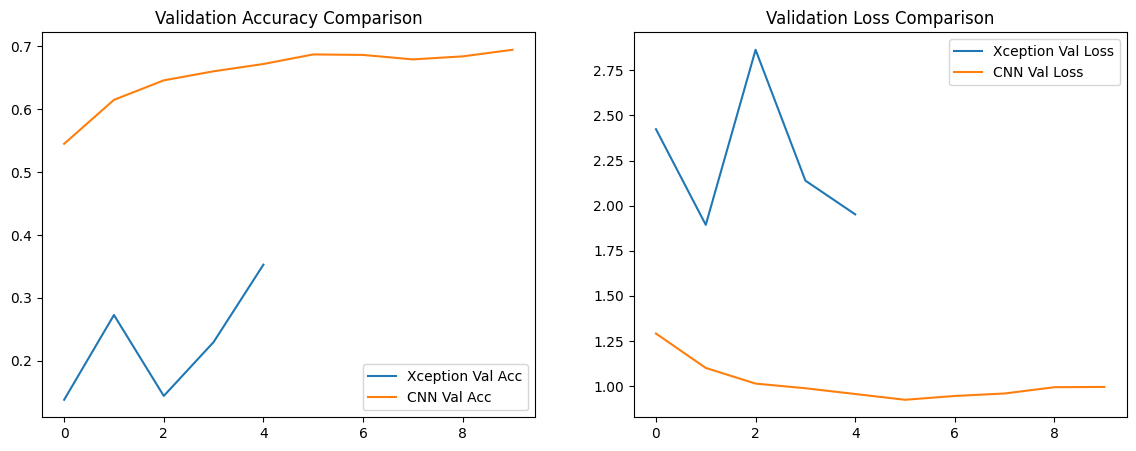

In [13]:
compare_models(model_xception, model_cnn, history_xception, history_cnn)

## 📊 Performance Comparison

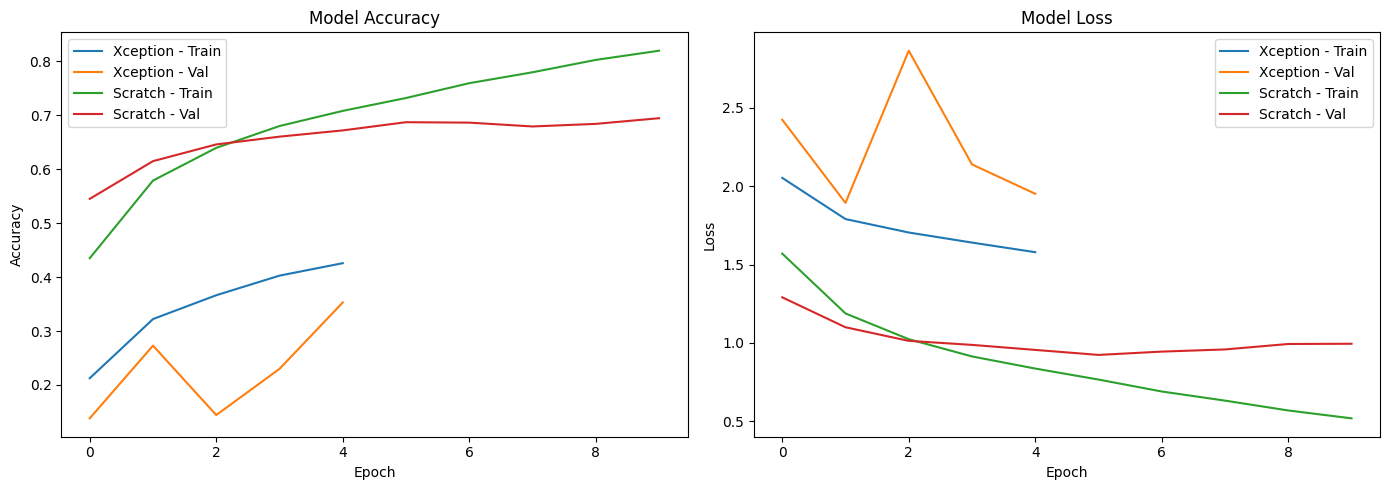

In [14]:
# Plot accuracy
plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_xception.history['accuracy'], label='Xception - Train')
plt.plot(history_xception.history['val_accuracy'], label='Xception - Val')
plt.plot(history_cnn.history['accuracy'], label='Scratch - Train')
plt.plot(history_cnn.history['val_accuracy'], label='Scratch - Val')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_xception.history['loss'], label='Xception - Train')
plt.plot(history_xception.history['val_loss'], label='Xception - Val')
plt.plot(history_cnn.history['loss'], label='Scratch - Train')
plt.plot(history_cnn.history['val_loss'], label='Scratch - Val')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()



### 📋 Model Comparison Summary

| Metric              | Fine-tuned Xception | CNN from Scratch |
|---------------------|---------------------|------------------|
| Training Time       | Fast (fewer epochs) | Longer (more epochs) |
| Number of Parameters| `model_xception.count_params()` | `model_scratch.count_params()` |
| Validation Accuracy | `max(history_xception.history['val_accuracy'])` | `max(history_scratch.history['val_accuracy'])` |
| Generalization      | Good (pretrained on ImageNet) | May overfit if small |
| Input Size          | Resized to 150x150 | Native 32x32 or same |

🔍 Xception benefits from transfer learning, achieving high accuracy faster. Scratch CNN requires more tuning and training time but offers flexibility.


In [15]:
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time/60:.1f} minutes")

Elapsed time: 12.8 minutes


Saturday 8pm - Elapsed time: 12.8 minutes